# 04. Modeling

이 노트북은 `03_baseline.ipynb`의 best baseline인 `HistGradientBoosting_log_target`을 기준으로 개선 실험을 수행합니다.

목표는 아래 세 가지입니다.

- v1 피처셋에서 추가 파생 피처를 만든 v2 피처셋 생성
- v1/v2, clipping, HGBR 하이퍼파라미터 후보를 동일한 5-fold RMSLE로 비교
- 최종 modeling 후보를 선택하고 다음 submission 단계에서 사용할 기준을 기록


In [1]:
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline

RANDOM_STATE = 42
N_SPLITS = 5

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCEED_DIR = PROJECT_ROOT / "data" / "proceed"
TRAIN_V1_PATH = PROCEED_DIR / "train_fe_v1.csv"
TEST_V1_PATH = PROCEED_DIR / "test_fe_v1.csv"
TRAIN_V2_PATH = PROCEED_DIR / "train_fe_v2.csv"
TEST_V2_PATH = PROCEED_DIR / "test_fe_v2.csv"

ID_COL = "id"
TARGET = "Rings"

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.6f}".format)
sns.set_theme(style="whitegrid", context="notebook")


## 1. Load v1 Feature Dataset

v1은 baseline에서 사용한 고정 피처셋입니다. modeling 실험도 이 파일을 출발점으로 삼습니다.


In [2]:
train_v1 = pd.read_csv(TRAIN_V1_PATH)
test_v1 = pd.read_csv(TEST_V1_PATH)

v1_feature_cols = [c for c in train_v1.columns if c not in [ID_COL, TARGET]]
X_v1 = train_v1[v1_feature_cols]
y = train_v1[TARGET]
X_test_v1 = test_v1[v1_feature_cols]

print(f"train_v1: {train_v1.shape}")
print(f"test_v1 : {test_v1.shape}")
print(f"v1 features: {len(v1_feature_cols)}")

display(train_v1.head())


train_v1: (90615, 19)
test_v1 : (60411, 18)
v1 features: 17


,id,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Height_is_zero,Volume,Density,Shucked_ratio,Viscera_ratio,Shell_ratio,Shell_to_shucked,Sex_F,Sex_I,Sex_M,Rings
0,0,0.550000,0.430000,0.150000,0.771500,0.328500,0.146500,0.240000,0,0.035475,21.747710,0.425794,0.189890,0.311082,0.730594,1,0,0,11
1,1,0.630000,0.490000,0.145000,1.130000,0.458000,0.276500,0.320000,0,0.044761,25.244909,0.405310,0.244690,0.283186,0.698690,1,0,0,11
2,2,0.160000,0.110000,0.025000,0.021000,0.005500,0.003000,0.005000,0,0.000440,47.727273,0.261905,0.142857,0.238095,0.909091,0,1,0,6
3,3,0.595000,0.475000,0.150000,0.914500,0.375500,0.205500,0.250000,0,0.042394,21.571576,0.410607,0.224713,0.273373,0.665779,0,0,1,10
4,4,0.555000,0.425000,0.130000,0.782000,0.369500,0.160000,0.197500,0,0.030664,25.502426,0.472506,0.204604,0.252558,0.534506,0,1,0,9


## 2. Build v2 Feature Dataset

v2는 v1에 shape ratio, component weight balance, log 피처를 추가한 실험용 피처셋입니다. 파생 피처의 결측/무한대 값은 train median으로 채웁니다.


In [3]:
def safe_divide(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    return numerator / denominator.replace(0, np.nan)


def add_v2_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["Area"] = out["Length"] * out["Diameter"]
    out["Diameter_to_Length"] = safe_divide(out["Diameter"], out["Length"])
    out["Height_to_Length"] = safe_divide(out["Height"], out["Length"])
    out["Height_to_Diameter"] = safe_divide(out["Height"], out["Diameter"])

    out["Component_weight_sum"] = out["Shucked_weight"] + out["Viscera_weight"] + out["Shell_weight"]
    out["Component_sum_ratio"] = safe_divide(out["Component_weight_sum"], out["Whole_weight"])
    out["Residual_weight"] = out["Whole_weight"] - out["Component_weight_sum"]
    out["Residual_weight_ratio"] = safe_divide(out["Residual_weight"], out["Whole_weight"])

    out["Whole_weight_to_Length"] = safe_divide(out["Whole_weight"], out["Length"])
    out["Whole_weight_to_Area"] = safe_divide(out["Whole_weight"], out["Area"])
    out["Whole_weight_to_Volume"] = safe_divide(out["Whole_weight"], out["Volume"])
    out["Shucked_to_Shell"] = safe_divide(out["Shucked_weight"], out["Shell_weight"])
    out["Viscera_to_Shell"] = safe_divide(out["Viscera_weight"], out["Shell_weight"])

    for col in ["Length", "Diameter", "Height", "Whole_weight", "Shucked_weight", "Viscera_weight", "Shell_weight", "Volume", "Density"]:
        out[f"log1p_{col}"] = np.log1p(out[col].clip(lower=0))

    return out.replace([np.inf, -np.inf], np.nan)

train_v2 = add_v2_features(train_v1)
test_v2 = add_v2_features(test_v1)

v2_feature_cols = [c for c in train_v2.columns if c not in [ID_COL, TARGET]]
median_fill_values = train_v2[v2_feature_cols].median(numeric_only=True)
train_v2[v2_feature_cols] = train_v2[v2_feature_cols].fillna(median_fill_values)
test_v2[v2_feature_cols] = test_v2[v2_feature_cols].fillna(median_fill_values)

train_v2 = train_v2[[ID_COL, *v2_feature_cols, TARGET]]
test_v2 = test_v2[[ID_COL, *v2_feature_cols]]

print(f"train_v2: {train_v2.shape}")
print(f"test_v2 : {test_v2.shape}")
print(f"v2 features: {len(v2_feature_cols)}")
print(f"new features: {len(set(v2_feature_cols) - set(v1_feature_cols))}")

display(pd.Series(sorted(set(v2_feature_cols) - set(v1_feature_cols)), name="new_v2_feature"))
display(train_v2.head())


train_v2: (90615, 41)
test_v2 : (60411, 40)
v2 features: 39
new features: 22


0                       Area
1        Component_sum_ratio
2       Component_weight_sum
3         Diameter_to_Length
4         Height_to_Diameter
5           Height_to_Length
6            Residual_weight
7      Residual_weight_ratio
8           Shucked_to_Shell
9           Viscera_to_Shell
10      Whole_weight_to_Area
11    Whole_weight_to_Length
12    Whole_weight_to_Volume
13             log1p_Density
14            log1p_Diameter
15              log1p_Height
16              log1p_Length
17        log1p_Shell_weight
18      log1p_Shucked_weight
19      log1p_Viscera_weight
20              log1p_Volume
21        log1p_Whole_weight
Name: new_v2_feature, dtype: str

,id,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Height_is_zero,Volume,Density,Shucked_ratio,Viscera_ratio,Shell_ratio,Shell_to_shucked,Sex_F,Sex_I,Sex_M,Area,Diameter_to_Length,Height_to_Length,Height_to_Diameter,Component_weight_sum,Component_sum_ratio,Residual_weight,Residual_weight_ratio,Whole_weight_to_Length,Whole_weight_to_Area,Whole_weight_to_Volume,Shucked_to_Shell,Viscera_to_Shell,log1p_Length,log1p_Diameter,log1p_Height,log1p_Whole_weight,log1p_Shucked_weight,log1p_Viscera_weight,log1p_Shell_weight,log1p_Volume,log1p_Density,Rings
0,0,0.550000,0.430000,0.150000,0.771500,0.328500,0.146500,0.240000,0,0.035475,21.747710,0.425794,0.189890,0.311082,0.730594,1,0,0,0.236500,0.781818,0.272727,0.348837,0.715000,0.926766,0.056500,0.073234,1.402727,3.262156,21.747710,1.368750,0.610417,0.438255,0.357674,0.139762,0.571827,0.284050,0.136714,0.215111,0.034860,3.124464,11
1,1,0.630000,0.490000,0.145000,1.130000,0.458000,0.276500,0.320000,0,0.044761,25.244909,0.405310,0.244690,0.283186,0.698690,1,0,0,0.308700,0.777778,0.230159,0.295918,1.054500,0.933186,0.075500,0.066814,1.793651,3.660512,25.244909,1.431250,0.864063,0.488580,0.398776,0.135405,0.756122,0.377066,0.244122,0.277632,0.043789,3.267472,11
2,2,0.160000,0.110000,0.025000,0.021000,0.005500,0.003000,0.005000,0,0.000440,47.727273,0.261905,0.142857,0.238095,0.909091,0,1,0,0.017600,0.687500,0.156250,0.227273,0.013500,0.642857,0.007500,0.357143,0.131250,1.193182,47.727273,1.100000,0.600000,0.148420,0.104360,0.024693,0.020783,0.005485,0.002996,0.004988,0.000440,3.886239,6
3,3,0.595000,0.475000,0.150000,0.914500,0.375500,0.205500,0.250000,0,0.042394,21.571576,0.410607,0.224713,0.273373,0.665779,0,0,1,0.282625,0.798319,0.252101,0.315789,0.831000,0.908693,0.083500,0.091307,1.536975,3.235736,21.571576,1.502000,0.822000,0.466874,0.388658,0.139762,0.649456,0.318817,0.186894,0.223144,0.041520,3.116691,10
4,4,0.555000,0.425000,0.130000,0.782000,0.369500,0.160000,0.197500,0,0.030664,25.502426,0.472506,0.204604,0.252558,0.534506,0,1,0,0.235875,0.765766,0.234234,0.305882,0.727000,0.929668,0.055000,0.070332,1.409009,3.315315,25.502426,1.870886,0.810127,0.441476,0.354172,0.122218,0.577736,0.314446,0.148420,0.180236,0.030203,3.277236,9


## 3. Validate and Save v2 Feature Files

v2 feature dataset은 이후 submission 단계에서도 재사용할 수 있도록 `data/proceed`에 저장합니다.


In [4]:
def validate_feature_frame(train_df: pd.DataFrame, test_df: pd.DataFrame, features: list[str]) -> None:
    assert train_df[ID_COL].is_unique and test_df[ID_COL].is_unique, "id must be unique."
    assert features == [c for c in test_df.columns if c != ID_COL], "train/test feature schema differs."
    assert train_df[features + [TARGET]].isna().sum().sum() == 0, "train has missing values."
    assert test_df[features].isna().sum().sum() == 0, "test has missing values."
    assert np.isfinite(train_df[features + [TARGET]].to_numpy()).all(), "train has non-finite values."
    assert np.isfinite(test_df[features].to_numpy()).all(), "test has non-finite values."
    assert train_df[TARGET].equals(train_v1[TARGET]), "target changed unexpectedly."

validate_feature_frame(train_v2, test_v2, v2_feature_cols)

train_v2.to_csv(TRAIN_V2_PATH, index=False)
test_v2.to_csv(TEST_V2_PATH, index=False)

print(f"Saved: {TRAIN_V2_PATH.relative_to(PROJECT_ROOT)}")
print(f"Saved: {TEST_V2_PATH.relative_to(PROJECT_ROOT)}")

display(
    pd.DataFrame(
        {
            "dataset": ["train_v2", "test_v2"],
            "rows": [len(train_v2), len(test_v2)],
            "columns": [train_v2.shape[1], test_v2.shape[1]],
            "missing_cells": [train_v2.isna().sum().sum(), test_v2.isna().sum().sum()],
        }
    )
)


Saved: data/proceed/train_fe_v2.csv
Saved: data/proceed/test_fe_v2.csv


,dataset,rows,columns,missing_cells
0,train_v2,90615,41,0
1,test_v2,60411,40,0


## 4. Metric, Split, and Helpers

RMSLE 기준은 baseline과 동일하게 유지합니다. clipping은 pipeline transformer로 넣어 fold별 train split에서만 분위수 경계를 학습하게 합니다.


In [5]:
def rmsle(y_true: np.ndarray | pd.Series, y_pred: np.ndarray | pd.Series) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))


def make_stratification_bins(target: pd.Series, q: int = 10) -> pd.Series:
    bins = pd.qcut(target, q=q, labels=False, duplicates="drop")
    return bins.astype(int)


class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower: float = 0.005, upper: float = 0.995):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        self.columns_ = X_df.columns
        self.lower_bounds_ = X_df.quantile(self.lower)
        self.upper_bounds_ = X_df.quantile(self.upper)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=getattr(self, "columns_", None)).copy()
        return X_df.clip(lower=self.lower_bounds_, upper=self.upper_bounds_, axis=1)


def make_hgbr(
    *,
    learning_rate: float = 0.05,
    max_iter: int = 350,
    max_leaf_nodes: int = 31,
    min_samples_leaf: int = 20,
    l2_regularization: float = 0.01,
    random_state: int = RANDOM_STATE,
) -> HistGradientBoostingRegressor:
    return HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=learning_rate,
        max_iter=max_iter,
        max_leaf_nodes=max_leaf_nodes,
        min_samples_leaf=min_samples_leaf,
        l2_regularization=l2_regularization,
        early_stopping=True,
        random_state=random_state,
    )


def with_log_target(estimator):
    return TransformedTargetRegressor(
        regressor=estimator,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )

y_bins = make_stratification_bins(y)
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)


## 5. Experiment Definitions

먼저 v1 baseline 재현, v2 추가 피처 효과, clipping 효과, HGBR 튜닝 후보를 비교합니다.


In [6]:
feature_sets = {
    "v1": (X_v1, X_test_v1, v1_feature_cols),
    "v2": (train_v2[v2_feature_cols], test_v2[v2_feature_cols], v2_feature_cols),
}

experiment_specs = [
    {
        "experiment": "v1_hgb_log_baseline",
        "feature_set": "v1",
        "estimator": with_log_target(make_hgbr()),
    },
    {
        "experiment": "v2_hgb_log_baseline",
        "feature_set": "v2",
        "estimator": with_log_target(make_hgbr()),
    },
    {
        "experiment": "v2_hgb_log_clip_005_995",
        "feature_set": "v2",
        "estimator": with_log_target(make_pipeline(QuantileClipper(0.005, 0.995), make_hgbr())),
    },
    {
        "experiment": "v2_hgb_log_lr0035_iter650",
        "feature_set": "v2",
        "estimator": with_log_target(make_hgbr(learning_rate=0.035, max_iter=650, max_leaf_nodes=31, min_samples_leaf=25, l2_regularization=0.03)),
    },
    {
        "experiment": "v2_hgb_log_leaf45",
        "feature_set": "v2",
        "estimator": with_log_target(make_hgbr(learning_rate=0.035, max_iter=600, max_leaf_nodes=45, min_samples_leaf=30, l2_regularization=0.04)),
    },
    {
        "experiment": "v2_hgb_log_leaf45_clip",
        "feature_set": "v2",
        "estimator": with_log_target(
            make_pipeline(
                QuantileClipper(0.005, 0.995),
                make_hgbr(learning_rate=0.035, max_iter=600, max_leaf_nodes=45, min_samples_leaf=30, l2_regularization=0.04),
            )
        ),
    },
]

pd.DataFrame([{k: v for k, v in spec.items() if k != "estimator"} for spec in experiment_specs])


,experiment,feature_set
0,v1_hgb_log_baseline,v1
1,v2_hgb_log_baseline,v2
2,v2_hgb_log_clip_005_995,v2
3,v2_hgb_log_lr0035_iter650,v2
4,v2_hgb_log_leaf45,v2
5,v2_hgb_log_leaf45_clip,v2


## 6. Cross-Validation Experiments

모든 실험은 같은 fold와 같은 RMSLE 함수로 비교합니다.


In [7]:
def evaluate_experiment(spec: dict):
    experiment = spec["experiment"]
    feature_set = spec["feature_set"]
    X_data, _, features = feature_sets[feature_set]
    estimator = spec["estimator"]

    rows = []
    oof_pred = np.zeros(len(y), dtype=float)

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_data, y_bins), start=1):
        X_train, X_valid = X_data.iloc[train_idx], X_data.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = clone(estimator)
        start = perf_counter()
        model.fit(X_train, y_train)
        fit_seconds = perf_counter() - start

        pred = np.clip(model.predict(X_valid), 0, None)
        score = rmsle(y_valid, pred)
        oof_pred[valid_idx] = pred

        rows.append(
            {
                "experiment": experiment,
                "feature_set": feature_set,
                "fold": fold,
                "n_features": len(features),
                "rmsle": score,
                "fit_seconds": fit_seconds,
                "prediction_min": pred.min(),
                "prediction_mean": pred.mean(),
                "prediction_max": pred.max(),
            }
        )
        print(f"{experiment:30s} fold {fold}: RMSLE={score:.6f}, fit={fit_seconds:.1f}s")

    return rows, oof_pred

experiment_rows = []
oof_predictions = {}

for spec in experiment_specs:
    rows, oof_pred = evaluate_experiment(spec)
    experiment_rows.extend(rows)
    oof_predictions[spec["experiment"]] = oof_pred

experiment_results = pd.DataFrame(experiment_rows)
experiment_summary = (
    experiment_results
    .groupby(["experiment", "feature_set", "n_features"], as_index=False)
    .agg(
        rmsle_mean=("rmsle", "mean"),
        rmsle_std=("rmsle", "std"),
        fit_seconds_total=("fit_seconds", "sum"),
        pred_min=("prediction_min", "min"),
        pred_mean=("prediction_mean", "mean"),
        pred_max=("prediction_max", "max"),
    )
    .sort_values("rmsle_mean")
    .reset_index(drop=True)
)

best_experiment = experiment_summary.loc[0, "experiment"]
best_feature_set = experiment_summary.loc[0, "feature_set"]
best_oof_pred = oof_predictions[best_experiment]
best_oof_rmsle = rmsle(y, best_oof_pred)

print("\nExperiment summary")
print(experiment_summary.to_string(index=False))
print(f"\nBest experiment: {best_experiment}")
print(f"Best feature set: {best_feature_set}")
print(f"Best OOF RMSLE: {best_oof_rmsle:.6f}")

display(experiment_results)
display(experiment_summary)


v1_hgb_log_baseline            fold 1: RMSLE=0.148950, fit=1.3s


v1_hgb_log_baseline            fold 2: RMSLE=0.149429, fit=0.8s


v1_hgb_log_baseline            fold 3: RMSLE=0.150157, fit=0.8s


v1_hgb_log_baseline            fold 4: RMSLE=0.149752, fit=0.7s


v1_hgb_log_baseline            fold 5: RMSLE=0.151296, fit=0.9s


...

v2_hgb_log_leaf45_clip         fold 3: RMSLE=0.149889, fit=2.3s


v2_hgb_log_leaf45_clip         fold 4: RMSLE=0.149550, fit=2.3s


v2_hgb_log_leaf45_clip         fold 5: RMSLE=0.151355, fit=2.2s

Experiment summary
               experiment feature_set  n_features  rmsle_mean  rmsle_std  fit_seconds_total  pred_min  pred_mean  pred_max
   v2_hgb_log_leaf45_clip          v2          39    0.149826   0.000907          11.497533  3.848877   9.564277 19.467874
        v2_hgb_log_leaf45          v2          39    0.149875   0.000856           9.359339  3.860389   9.563315 19.628542
      v1_hgb_log_baseline          v1          17    0.149917   0.000889           4.555807  3.598721   9.563321 19.746096
v2_hgb_log_lr0035_iter650          v2          39    0.149947   0.000891           8.478499  3.779188   9.563618 19.489910
  v2_hgb_log_clip_005_995          v2          39    0.149987   0.000932           7.854526  3.777720   9.564469 20.069133
      v2_hgb_log_baseline          v2          39    0.150008   0.000911           6.360851  3.745244   9.563799 19.612441

Best experiment: v2_hgb_log_leaf45_clip
Best feature s

,experiment,feature_set,fold,n_features,rmsle,fit_seconds,prediction_min,prediction_mean,prediction_max
0,v1_hgb_log_baseline,v1,1,17,0.148950,1.342025,3.598721,9.565118,19.276607
1,v1_hgb_log_baseline,v1,2,17,0.149429,0.776882,3.960100,9.565724,19.609310
2,v1_hgb_log_baseline,v1,3,17,0.150157,0.821100,3.926052,9.557372,19.745381
3,v1_hgb_log_baseline,v1,4,17,0.149752,0.728570,3.855502,9.563310,19.175387
4,v1_hgb_log_baseline,v1,5,17,0.151296,0.887229,3.892562,9.565080,19.746096
5,v2_hgb_log_baseline,v2,1,39,0.149345,1.497459,3.745244,9.565929,19.298389
6,v2_hgb_log_baseline,v2,2,39,0.149276,1.347682,3.922345,9.566183,19.562550
7,v2_hgb_log_baseline,v2,3,39,0.150310,1.093950,3.944524,9.555102,19.446789
8,v2_hgb_log_baseline,v2,4,39,0.149646,1.234331,3.859162,9.566748,18.616741
9,v2_hgb_log_baseline,v2,5,39,0.151464,1.187430,3.962864,9.565032,19.612441


,experiment,feature_set,n_features,rmsle_mean,rmsle_std,fit_seconds_total,pred_min,pred_mean,pred_max
0,v2_hgb_log_leaf45_clip,v2,39,0.149826,0.000907,11.497533,3.848877,9.564277,19.467874
1,v2_hgb_log_leaf45,v2,39,0.149875,0.000856,9.359339,3.860389,9.563315,19.628542
2,v1_hgb_log_baseline,v1,17,0.149917,0.000889,4.555807,3.598721,9.563321,19.746096
3,v2_hgb_log_lr0035_iter650,v2,39,0.149947,0.000891,8.478499,3.779188,9.563618,19.489910
4,v2_hgb_log_clip_005_995,v2,39,0.149987,0.000932,7.854526,3.777720,9.564469,20.069133
5,v2_hgb_log_baseline,v2,39,0.150008,0.000911,6.360851,3.745244,9.563799,19.612441


## 7. Experiment Visualization

v1 baseline 대비 개선폭과 fold별 안정성을 확인합니다.


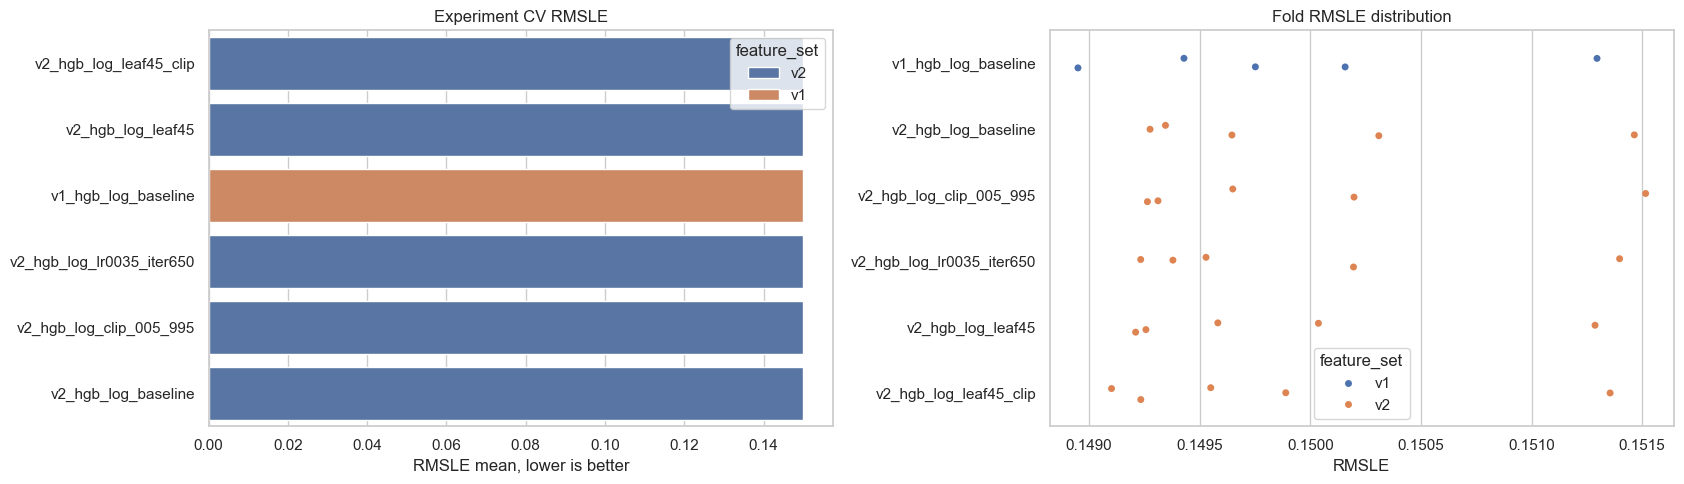

,experiment,feature_set,n_features,rmsle_mean,rmsle_std,fit_seconds_total,pred_min,pred_mean,pred_max,delta_vs_v1_baseline
0,v2_hgb_log_leaf45_clip,v2,39,0.149826,0.000907,11.497533,3.848877,9.564277,19.467874,-0.000091
1,v2_hgb_log_leaf45,v2,39,0.149875,0.000856,9.359339,3.860389,9.563315,19.628542,-0.000042
2,v1_hgb_log_baseline,v1,17,0.149917,0.000889,4.555807,3.598721,9.563321,19.746096,0.000000
3,v2_hgb_log_lr0035_iter650,v2,39,0.149947,0.000891,8.478499,3.779188,9.563618,19.489910,0.000030
4,v2_hgb_log_clip_005_995,v2,39,0.149987,0.000932,7.854526,3.777720,9.564469,20.069133,0.000071
5,v2_hgb_log_baseline,v2,39,0.150008,0.000911,6.360851,3.745244,9.563799,19.612441,0.000091


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

sns.barplot(data=experiment_summary, y="experiment", x="rmsle_mean", hue="feature_set", dodge=False, ax=axes[0])
axes[0].set_title("Experiment CV RMSLE")
axes[0].set_xlabel("RMSLE mean, lower is better")
axes[0].set_ylabel("")

sns.stripplot(data=experiment_results, y="experiment", x="rmsle", hue="feature_set", dodge=False, ax=axes[1])
axes[1].set_title("Fold RMSLE distribution")
axes[1].set_xlabel("RMSLE")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

baseline_score = experiment_summary.loc[experiment_summary["experiment"].eq("v1_hgb_log_baseline"), "rmsle_mean"].iloc[0]
experiment_summary.assign(delta_vs_v1_baseline=experiment_summary["rmsle_mean"] - baseline_score)


## 8. Best Experiment OOF Diagnostics

best experiment의 OOF 예측으로 타깃 구간별 오차를 확인합니다.


In [9]:
oof_df = pd.DataFrame(
    {
        "id": train_v1[ID_COL],
        "Rings": y,
        "prediction": best_oof_pred,
    }
)
oof_df["residual"] = oof_df["prediction"] - oof_df["Rings"]
oof_df["abs_error"] = oof_df["residual"].abs()

oof_by_ring_rows = []
for ring, group in oof_df.groupby("Rings"):
    oof_by_ring_rows.append(
        {
            "Rings": ring,
            "count": len(group),
            "prediction_mean": group["prediction"].mean(),
            "residual_mean": group["residual"].mean(),
            "abs_error_mean": group["abs_error"].mean(),
            "rmsle": rmsle(group["Rings"], group["prediction"]),
        }
    )

oof_by_ring = pd.DataFrame(oof_by_ring_rows)

print(f"Best experiment: {best_experiment}")
print(f"OOF RMSLE: {best_oof_rmsle:.6f}")
display(oof_df.describe().T)
display(oof_by_ring)


Best experiment: v2_hgb_log_leaf45_clip
OOF RMSLE: 0.149828


,count,mean,std,min,25%,50%,75%,max
id,90615.000000,45307.000000,26158.441658,0.000000,22653.500000,45307.000000,67960.500000,90614.000000
Rings,90615.000000,9.696794,3.176221,1.000000,8.000000,9.000000,11.000000,29.000000
prediction,90615.000000,9.564277,2.502971,3.848877,7.932561,9.392477,10.963873,19.467874
residual,90615.000000,-0.132517,1.849523,-20.376047,-0.757367,0.134986,0.860351,10.578715
abs_error,90615.000000,1.226365,1.390795,0.000022,0.368064,0.816802,1.536431,20.376047


,Rings,count,prediction_mean,residual_mean,abs_error_mean,rmsle
0,1,25,8.794725,7.794725,7.794725,1.583845
1,2,29,6.875791,4.875791,4.875791,0.965511
2,3,386,4.693808,1.693808,1.693808,0.363775
3,4,1402,4.585323,0.585323,0.587944,0.139115
4,5,2862,5.379985,0.379985,0.662472,0.126683
5,6,5411,6.502402,0.502402,0.788030,0.129827
6,7,9008,7.333372,0.333372,0.693007,0.111077
7,8,14499,8.470601,0.470601,0.875291,0.119640
8,9,17465,9.423028,0.423028,0.864017,0.112540
9,10,12464,10.346836,0.346836,1.016014,0.117324


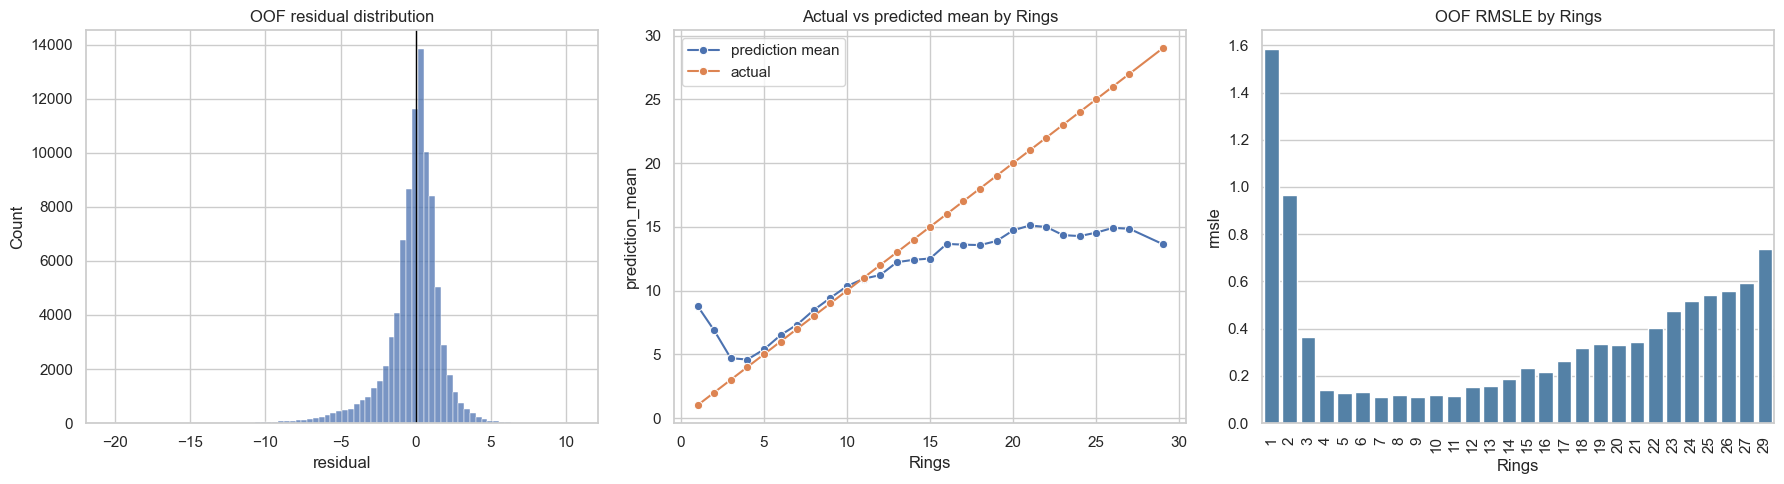

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(oof_df["residual"], bins=80, ax=axes[0])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("OOF residual distribution")

sns.lineplot(data=oof_by_ring, x="Rings", y="prediction_mean", marker="o", label="prediction mean", ax=axes[1])
sns.lineplot(data=oof_by_ring, x="Rings", y="Rings", marker="o", label="actual", ax=axes[1])
axes[1].set_title("Actual vs predicted mean by Rings")

sns.barplot(data=oof_by_ring, x="Rings", y="rmsle", color="steelblue", ax=axes[2])
axes[2].set_title("OOF RMSLE by Rings")
axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


## 9. Feature Importance for Best Experiment

best experiment를 holdout split에 재학습하고 permutation importance를 확인합니다. 이 값은 다음 feature version을 설계하기 위한 참고용입니다.


Holdout RMSLE for importance model: 0.150510


,feature,importance_mean,importance_std
0,Shell_weight,0.114042,0.001509
1,Shell_to_shucked,0.008278,0.000089
2,Shucked_ratio,0.006716,0.000169
3,Shucked_to_Shell,0.004910,0.000039
4,Sex_I,0.004169,0.000144
5,Height,0.002629,0.000071
6,Whole_weight_to_Length,0.002052,0.000028
7,Whole_weight_to_Area,0.001951,0.000146
8,Viscera_weight,0.001238,0.000070
9,Height_to_Length,0.001007,0.000150


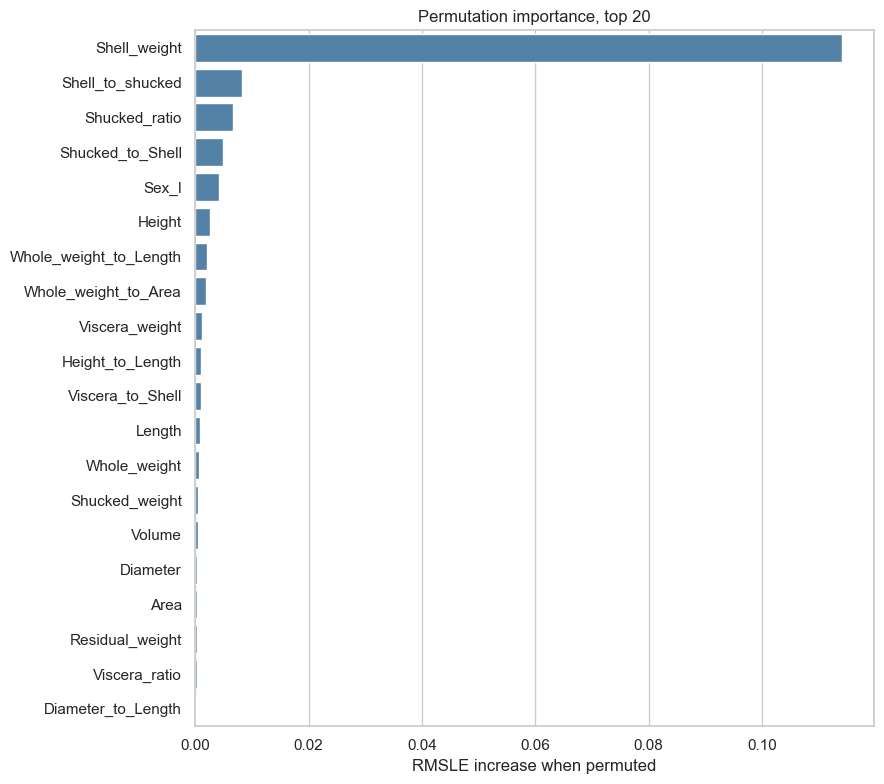

In [11]:
best_spec = next(spec for spec in experiment_specs if spec["experiment"] == best_experiment)
X_best, X_test_best, best_feature_cols = feature_sets[best_feature_set]

train_idx, valid_idx = train_test_split(
    np.arange(len(X_best)),
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_bins,
)

best_estimator = clone(best_spec["estimator"])
best_estimator.fit(X_best.iloc[train_idx], y.iloc[train_idx])
holdout_pred = np.clip(best_estimator.predict(X_best.iloc[valid_idx]), 0, None)
holdout_rmsle = rmsle(y.iloc[valid_idx], holdout_pred)

importance_sample_size = min(12_000, len(valid_idx))
rng = np.random.default_rng(RANDOM_STATE)
importance_idx = rng.choice(valid_idx, size=importance_sample_size, replace=False)

importance = permutation_importance(
    best_estimator,
    X_best.iloc[importance_idx],
    y.iloc[importance_idx],
    scoring=lambda estimator, X_valid, y_valid: -rmsle(y_valid, estimator.predict(X_valid)),
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame(
        {
            "feature": best_feature_cols,
            "importance_mean": importance.importances_mean,
            "importance_std": importance.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

print(f"Holdout RMSLE for importance model: {holdout_rmsle:.6f}")
display(importance_df.head(20))

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=importance_df.head(20), y="feature", x="importance_mean", ax=ax, color="steelblue")
ax.set_title("Permutation importance, top 20")
ax.set_xlabel("RMSLE increase when permuted")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 10. Test Prediction Sanity Check

최종 submission 파일은 `05_submission.ipynb`에서 생성합니다. 여기서는 best experiment를 전체 train에 학습시킨 뒤 test 예측 분포만 확인합니다.


,test_prediction
count,60411.000000
mean,9.570973
std,2.500669
min,3.932152
1%,4.352409
5%,5.627800
50%,9.396290
95%,14.248767
99%,16.484897
max,19.348445


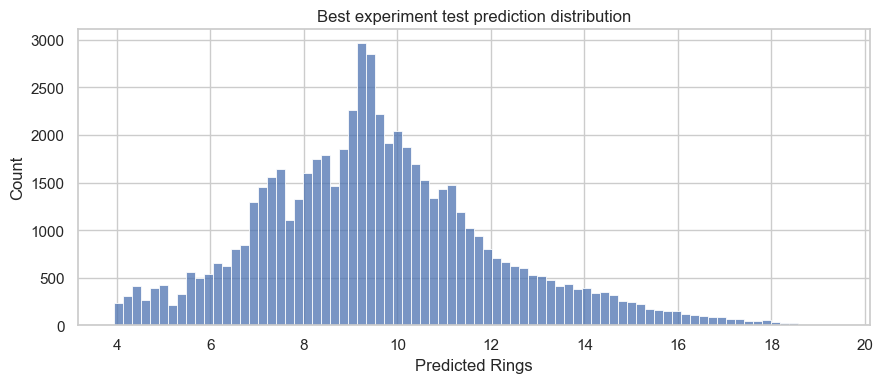

In [12]:
final_estimator = clone(best_spec["estimator"])
final_estimator.fit(X_best, y)
test_pred = np.clip(final_estimator.predict(X_test_best), 0, None)

prediction_summary = pd.Series(test_pred, name="test_prediction").describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).to_frame()

display(prediction_summary)

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(test_pred, bins=80, ax=ax)
ax.set_title("Best experiment test prediction distribution")
ax.set_xlabel("Predicted Rings")
plt.tight_layout()
plt.show()


## 11. Modeling Findings and Next Steps

- v2 피처셋을 `data/proceed/train_fe_v2.csv`, `data/proceed/test_fe_v2.csv`로 저장했습니다.
- 가장 좋은 실험은 `best_experiment` 변수에 저장되어 있으며, submission 단계에서는 같은 estimator와 feature set을 사용합니다.
- 다음 `05_submission.ipynb`에서는 선택된 feature set을 로드하고, 전체 train으로 최종 모델을 학습한 뒤 `sample_submission.csv` 형식의 제출 파일을 생성합니다.
- 추가 개선 후보는 `Rings` 고연령 구간의 오차 완화, feature v3, HGBR 외부 부스팅 모델 비교입니다.
